In [12]:
import pandas as pd
import numpy as np
from scipy.interpolate import make_interp_spline
import matplotlib.pyplot as plt

import re
import os

In [2]:
# Data
data_path = os.path.join("..", "data", "IPL Auction (2013-2026).xlsx")
data = pd.read_excel(data_path)

data.head()

,Team,Player,Role,Value,Year
0,Chennai Super Kings,Christopher Morris,All-Rounder,625000,2013
1,Chennai Super Kings,Dirk Nannes,Bowler,600000,2013
2,Chennai Super Kings,Ben Laughlin,Bowler,20000,2013
3,Chennai Super Kings,Akila Dananjaya,All-Rounder,20000,2013
4,Chennai Super Kings,Jason Holder,Bowler,20000,2013


In [3]:
data["Value"] = data["Value"].apply(lambda x: float(re.sub(r"[?,/]", "", x)) if isinstance(x, str) else float(x))

In [4]:
df = data.copy()

In [5]:
year_start = 2017

df2 = df[df["Year"]>=year_start]

In [6]:
df2.head()

,Team,Player,Role,Value,Year
352,Delhi Daredevils,Kagiso Rabada,Bowler,50000000.0,2017
353,Delhi Daredevils,Patrick Cummins,Bowler,45000000.0,2017
354,Delhi Daredevils,Angelo Mathews,All-Rounder,20000000.0,2017
355,Delhi Daredevils,Corey Anderson,All-Rounder,10000000.0,2017
356,Delhi Daredevils,M. Ashwin,Bowler,10000000.0,2017


In [7]:
# ------------------------------------------------------------
# 1) Global min-max scaled column
# ------------------------------------------------------------
df2 = df2.copy()

value_col = "Value"
year_col = "Year"

global_min = df2[value_col].min()
global_max = df2[value_col].max()
global_range = global_max - global_min

# guard against divide-by-zero (in case all values are identical)
df2["value_scaled"] = np.where(
    global_range == 0,
    0.5,
    (df2[value_col] - global_min) / global_range
)

In [8]:
# ------------------------------------------------------------
# 2) df_grouped: min, max, median, mean, n_players by year (ON SCALED)
# ------------------------------------------------------------
df_grouped = (
    df2.groupby(year_col, as_index=False)
       .agg(
           min_val=("value_scaled", "min"),
           max_val=("value_scaled", "max"),
           median_val=("value_scaled", "median"),
           mean_val=("value_scaled", "mean"),
           n_players=("value_scaled", "size"),
       )
       .sort_values(year_col)
       .reset_index(drop=True)
)


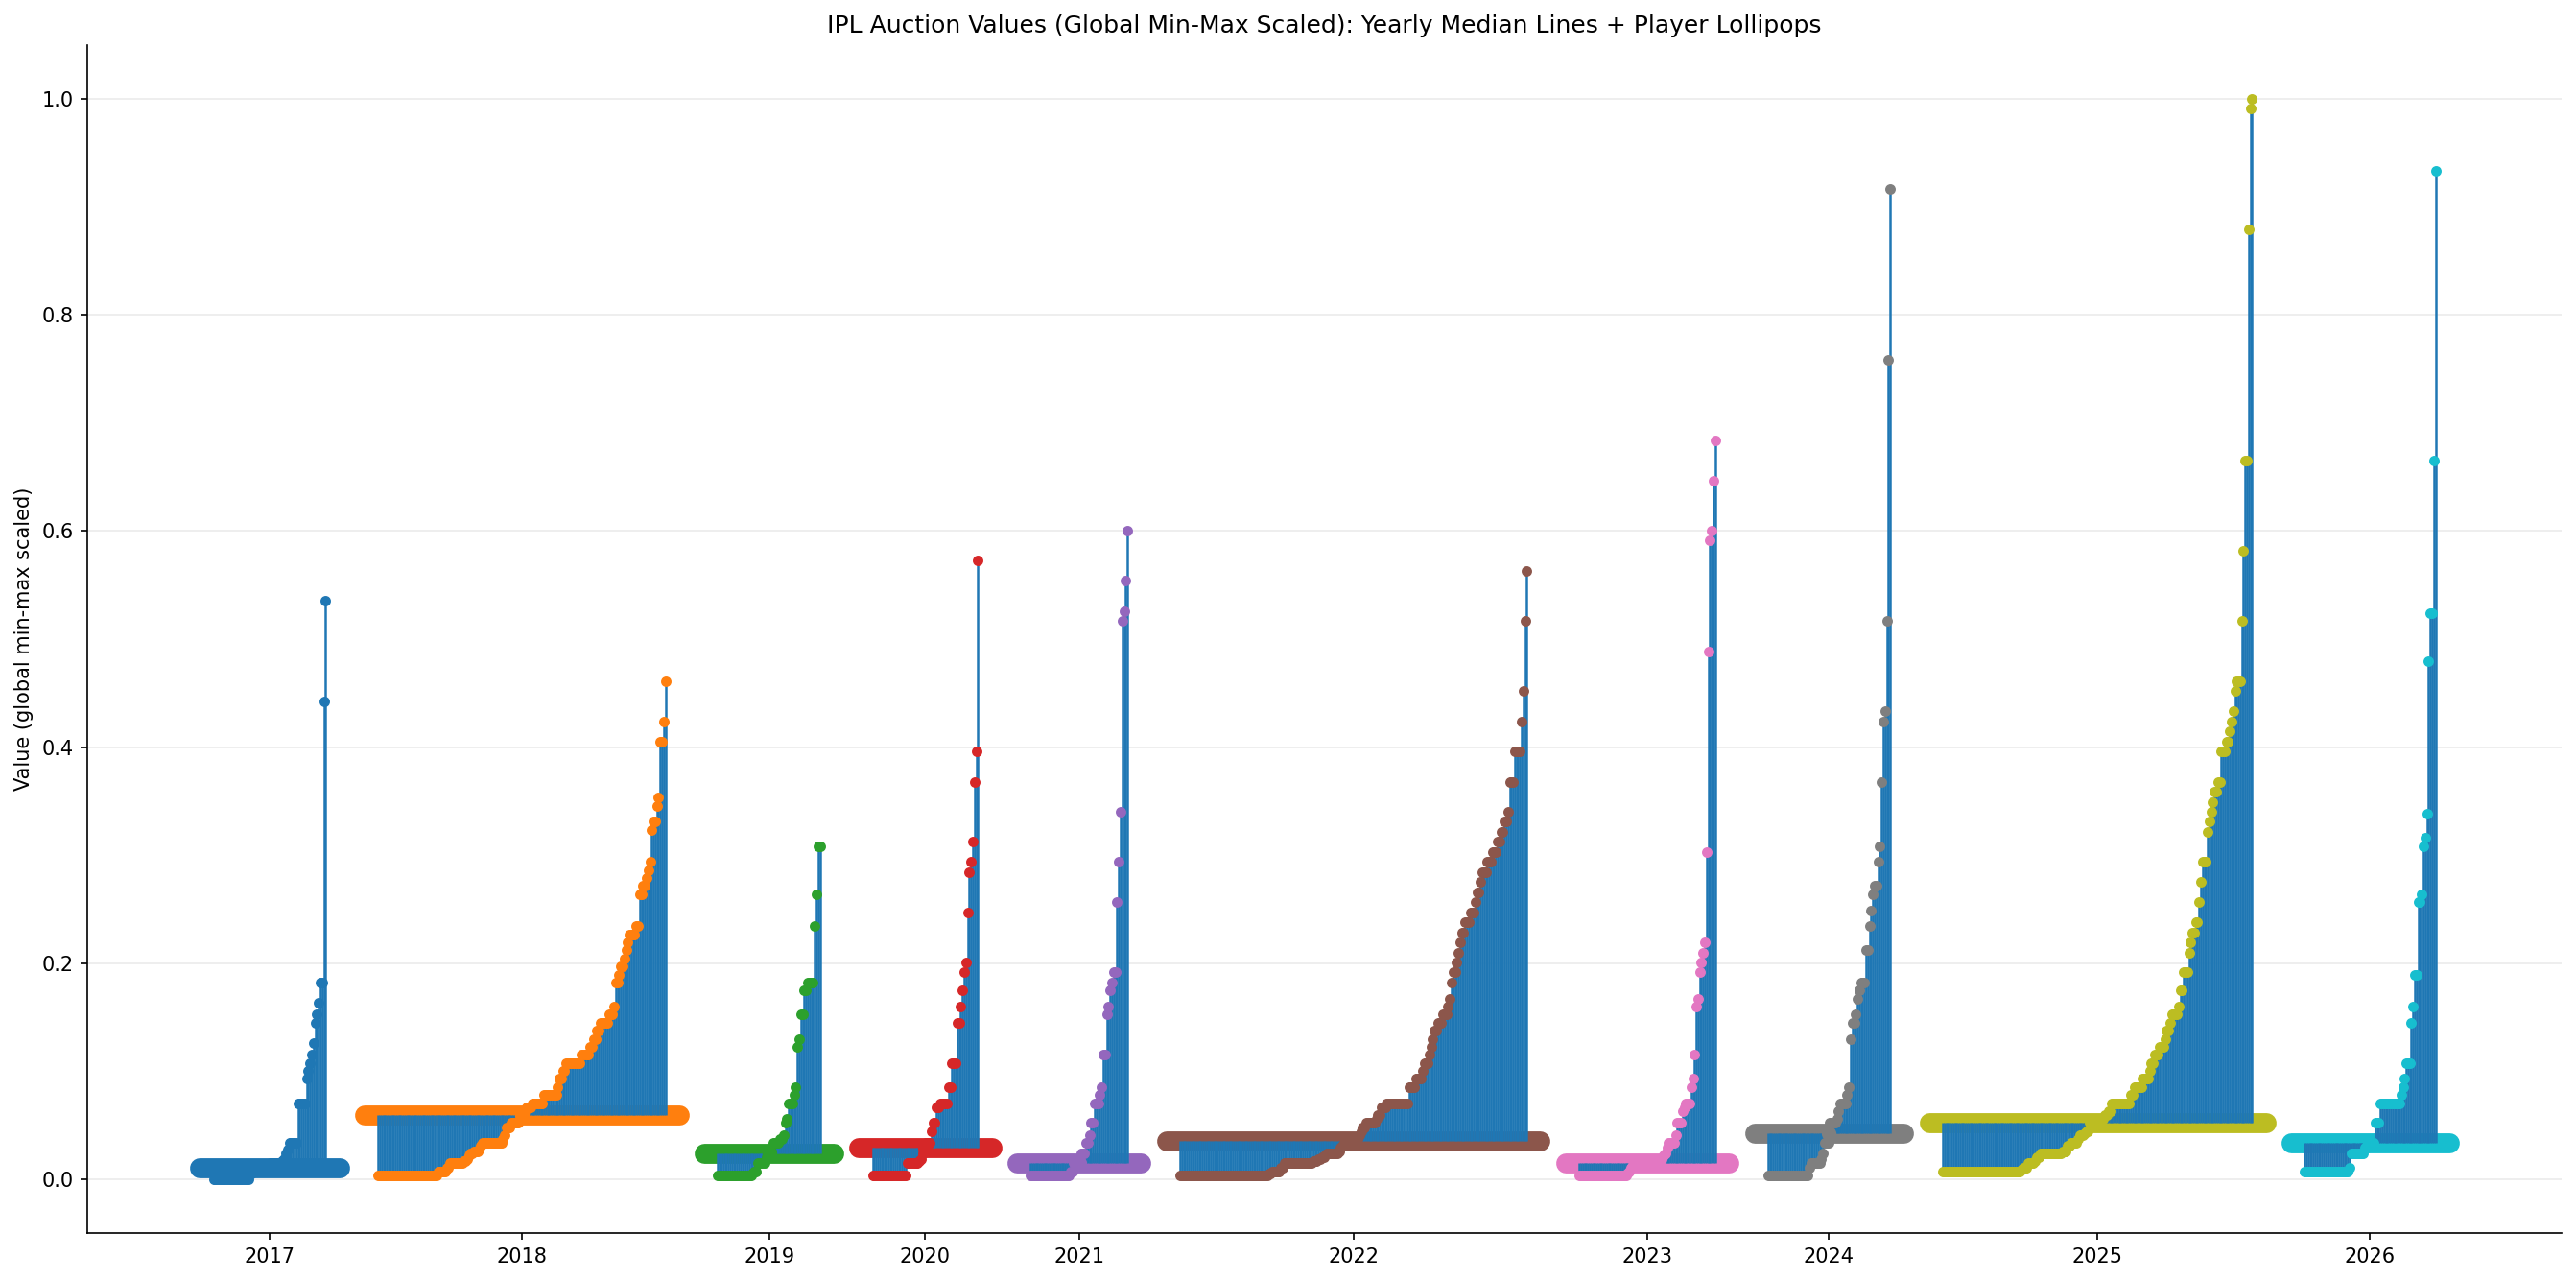

In [9]:
# ------------------------------------------------------------
# 3) Plot: thick median lines + lollipops for ALL player values (scaled)
#     - tweakables:
#       line_thickness
#       pad
#       x_offset
#       y_offset
# ------------------------------------------------------------
line_thickness = 10          # thickness of the thick median line
pad = 8                      # left & right pad added to line length (in x units)
gap = 15                     # extra gap between years (in x units)
x_offset = 0                 # shift entire chart right (in x units)
y_offset = 0                 # shift entire chart up (in y units)

fig, ax = plt.subplots(figsize=(18, 9), dpi=150)

# We'll place each year's "thick line" on a separate x segment,
# where segment length = n_players + pad*2 (as you requested).
x_cursor = 0

year_to_segment = {}  # store x_left, x_right, x_center for each year

for _, row in df_grouped.iterrows():
    year = int(row[year_col])
    n_players = int(row["n_players"])

    line_length = n_players + pad * 2
    x_left = x_cursor
    x_right = x_cursor + line_length
    x_center = (x_left + x_right) / 2

    year_to_segment[year] = (x_left, x_right, x_center)

    # thick median line (horizontal)
    y_median = row["median_val"] + y_offset
    ax.plot(
        [x_left + x_offset, x_right + x_offset],
        [y_median, y_median],
        linewidth=line_thickness,
        solid_capstyle="round"
    )

    # optional: median marker
    ax.scatter([x_center + x_offset], [y_median], s=40, zorder=4)

    # move cursor for next year
    x_cursor = x_right + gap

# Lollipops: for each year, distribute players across the thick line (excluding pads)
# and draw stems from median to each player's scaled value.
for year, (x_left, x_right, x_center) in year_to_segment.items():
    df_y = df2[df2[year_col] == year].sort_values("value_scaled").reset_index(drop=True)

    n_players = len(df_y)
    if n_players == 0:
        continue

    # x positions along the thick line, staying inside the pad region
    x_positions = np.linspace(
        x_left + pad + x_offset,
        x_right - pad + x_offset,
        n_players
    )

    # median y for stems
    y_median = df_grouped.loc[df_grouped[year_col] == year, "median_val"].iloc[0] + y_offset

    # player y values (scaled)
    y_values = df_y["value_scaled"].to_numpy() + y_offset

    # stems
    ax.vlines(
        x_positions,
        y_median,
        y_values,
        linewidth=1.2,
        zorder=2
    )

    # lollipop heads
    ax.scatter(
        x_positions,
        y_values,
        s=18,
        zorder=3
    )

# Year labels near the center of each segment
year_tick_pos = []
year_tick_lab = []
for year, (_, _, x_center) in year_to_segment.items():
    year_tick_pos.append(x_center + x_offset)
    year_tick_lab.append(str(year))

ax.set_xticks(year_tick_pos)
ax.set_xticklabels(year_tick_lab, rotation=0)

ax.set_ylim(-0.05 + y_offset, 1.05 + y_offset)
ax.set_ylabel("Value (global min-max scaled)")
ax.set_title("IPL Auction Values (Global Min-Max Scaled): Yearly Median Lines + Player Lollipops")

# Clean up
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

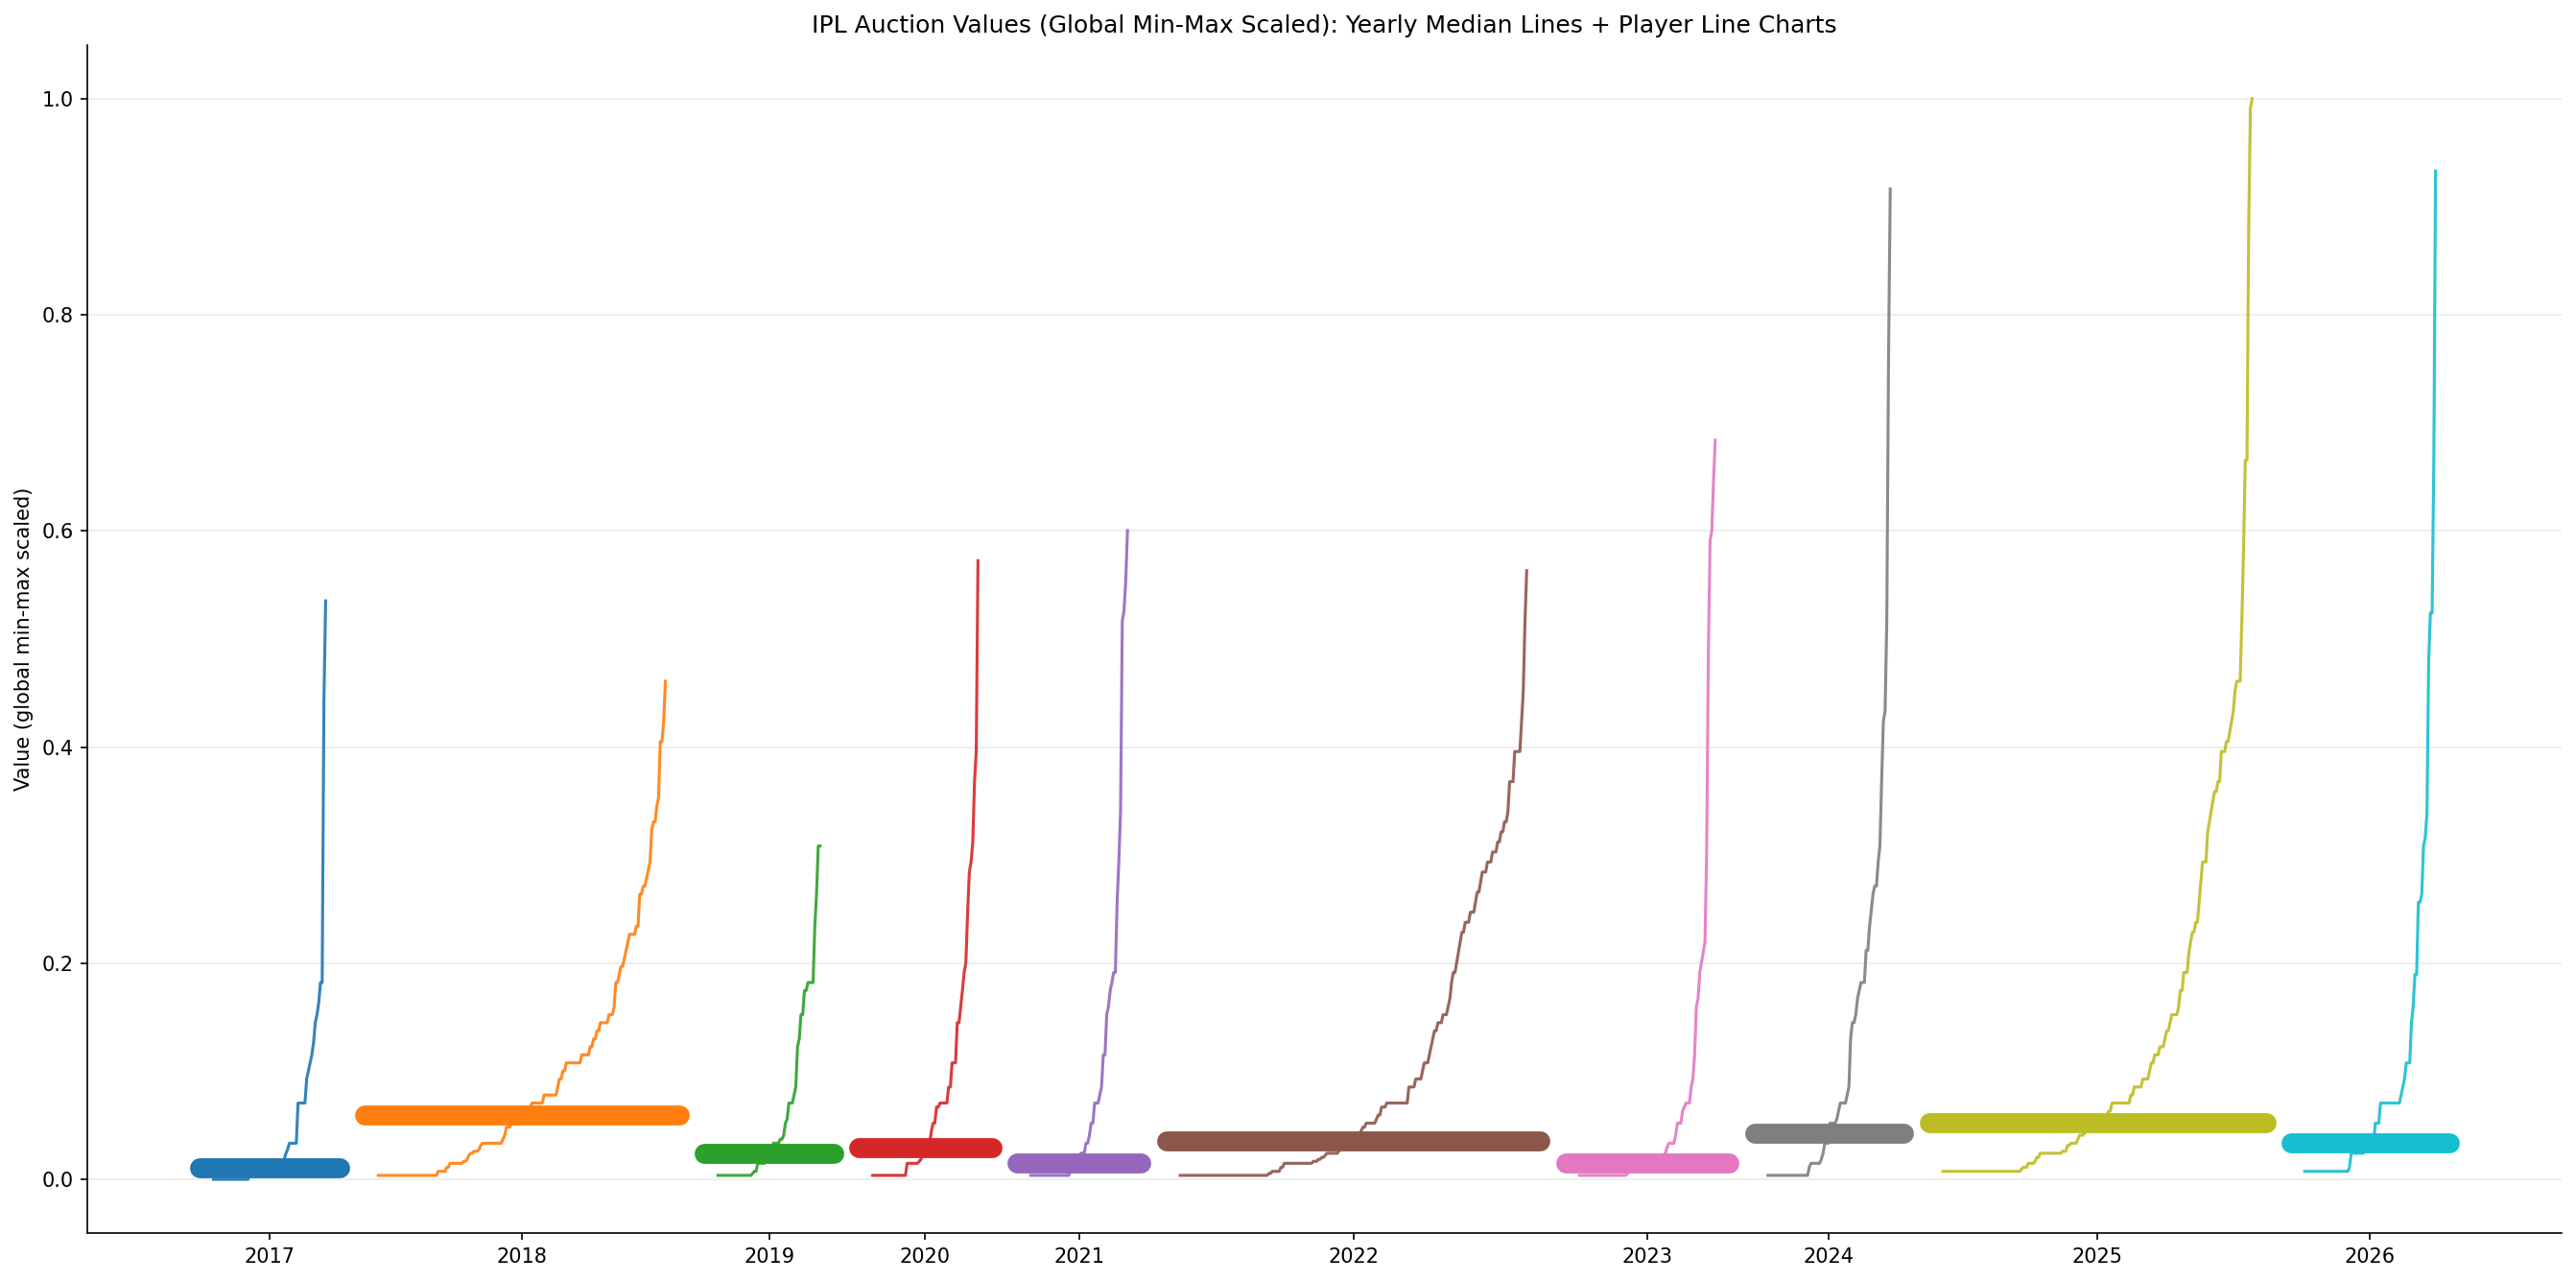

In [10]:
# ------------------------------------------------------------
# 3) Plot: thick median lines + per-year line chart of player values (scaled)
# ------------------------------------------------------------
line_thickness = 10      # thickness of the thick median line
pad = 8                  # left & right pad added to line length (in x units)
gap = 15                 # extra gap between years (in x units)
x_offset = 0             # shift entire chart right (in x units)
y_offset = 0             # shift entire chart up (in y units)

# Optional tweaks for the line chart
player_line_width = 1.5
player_line_alpha = 0.9
sort_players_by = "value_scaled"  # or "Value", or "Player" if you want deterministic order

fig, ax = plt.subplots(figsize=(18, 9), dpi=150)

x_cursor = 0
year_to_segment = {}  # year -> (x_left, x_right, x_center, n_players)

# --- draw thick median lines per year ---
for _, row in df_grouped.iterrows():
    year = int(row[year_col])
    n_players = int(row["n_players"])

    line_length = n_players + pad * 2
    x_left = x_cursor
    x_right = x_cursor + line_length
    x_center = (x_left + x_right) / 2

    year_to_segment[year] = (x_left, x_right, x_center, n_players)

    y_median = row["median_val"] + y_offset

    ax.plot(
        [x_left + x_offset, x_right + x_offset],
        [y_median, y_median],
        linewidth=line_thickness,
        solid_capstyle="round",
        zorder=1
    )

    # optional: median dot
    ax.scatter([x_center + x_offset], [y_median], s=40, zorder=3)

    x_cursor = x_right + gap

# --- draw per-year line charts (instead of lollipops) ---
for year, (x_left, x_right, _, n_players) in year_to_segment.items():
    df_y = df2[df2[year_col] == year].copy()

    if df_y.empty:
        continue

    df_y = df_y.sort_values(sort_players_by).reset_index(drop=True)

    # x positions along the thick line (inside pads)
    # if only 1 player, place at the center of the usable region
    if n_players == 1:
        x_positions = np.array([(x_left + pad + x_right - pad) / 2 + x_offset])
    else:
        x_positions = np.linspace(
            x_left + pad + x_offset,
            x_right - pad + x_offset,
            n_players
        )

    y_values = df_y["value_scaled"].to_numpy() + y_offset

    ax.plot(
        x_positions,
        y_values,
        linewidth=player_line_width,
        alpha=player_line_alpha,
        zorder=2
    )

# --- x ticks as years, centered on each segment ---
year_tick_pos = []
year_tick_lab = []
for year, (_, _, x_center, _) in year_to_segment.items():
    year_tick_pos.append(x_center + x_offset)
    year_tick_lab.append(str(year))

ax.set_xticks(year_tick_pos)
ax.set_xticklabels(year_tick_lab)

ax.set_ylim(-0.05 + y_offset, 1.05 + y_offset)
ax.set_ylabel("Value (global min-max scaled)")
ax.set_title("IPL Auction Values (Global Min-Max Scaled): Yearly Median Lines + Player Line Charts")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()